Predicción del Producto Interno Bruto (PIB) mediante Regresión Lineal utilizando indicadores económicos

**Pregunta de investigación**

¿En qué medida algunas variables demográficas y económicas permiten explicar y predecir el PIB de los países?
Variable objetivo

**PIB — Producto Interno Bruto en dólares corrientes**

Código del indicador Banco Mundial:

 `NY.GDP.MKTP.CD`

Predictores

Utilizaremos cinco:
| Variable                                    | Código Banco Mundial | Tipo         |
| ------------------------------------------- | -------------------- | ------------ |
| Población total                             | `SP.POP.TOTL`        | Predictor    |
| Exportaciones de bienes y servicios (% PIB) | `NE.EXP.GNFS.ZS`     | Predictor    |
| Importaciones de bienes y servicios (% PIB) | `NE.IMP.GNFS.ZS`     | Predictor    |
| Desempleo (% fuerza laboral)                | `SL.UEM.TOTL.ZS`     | Predictor    |
| Inflación, precios al consumidor (%)        | `FP.CPI.TOTL.ZG`     | Predictor    |
| **PIB (US$ corrientes)**                    | `NY.GDP.MKTP.CD`     | **Objetivo** |


# Predicción del Producto Interno Bruto mediante Regresión Lineal

## Semana 4 – Herramientas de Recolección de Datos

**Autor:** Yerson Ronaldo Rivas Ruiz  
**Curso:** Especialización en Análisis y Ciencia de Datos  
**Modelo:** Regresión Lineal  
**Fuente de datos:** Banco Mundial – World Development Indicators

In [13]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

np.random.seed(42)

print("Librerías cargadas correctamente.")


**Recolección de datos mediante API**

In [9]:
import requests
import pandas as pd

indicadores = {
    "PIB": "NY.GDP.MKTP.CD",
    "Poblacion": "SP.POP.TOTL",
    "Exportaciones": "NE.EXP.GNFS.ZS",
    "Importaciones": "NE.IMP.GNFS.ZS",
    "Desempleo": "SL.UEM.TOTL.ZS",
    "Inflacion": "FP.CPI.TOTL.ZG"
}

anio = 2023

def obtener_indicador(codigo, nombre):
    url = (
        f"https://api.worldbank.org/v2/country/all/"
        f"indicator/{codigo}?date={anio}&format=json&per_page=400"
    )

    respuesta = requests.get(url)
    respuesta.raise_for_status()

    datos = respuesta.json()[1]

    registros = []

    for dato in datos:
        if dato["value"] is not None:
            registros.append({
                "Codigo_Pais": dato["countryiso3code"],
                "Pais": dato["country"]["value"],
                nombre: dato["value"]
            })

    return pd.DataFrame(registros)

In [10]:
df = None

for nombre, codigo in indicadores.items():
    temporal = obtener_indicador(codigo, nombre)

    if df is None:
        df = temporal
    else:
        df = df.merge(
            temporal,
            on=["Codigo_Pais", "Pais"],
            how="inner"
        )

df.head()

,Codigo_Pais,Pais,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
0,AFE,Africa Eastern and Southern,1.179122e+12,750491370,26.160466,29.503507,7.676548,7.399186
1,ARB,Arab World,3.617895e+12,482105978,46.826824,40.466457,9.313389,4.000259
2,CEB,Central Europe and the Baltics,2.273564e+12,100183707,62.722090,59.796002,4.012304,9.442841
3,EAR,Early-demographic dividend,1.479149e+13,3511607650,26.120249,27.553578,5.113135,5.885859
4,EAS,East Asia & Pacific,3.159745e+13,2384441485,29.674608,27.392212,3.861870,4.251555


**Guardar el dataset**

In [14]:
df.to_csv(
    "datos_regresion.csv",
    index=False,
    encoding="utf-8"
)

print("Dataset guardado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset guardado correctamente.
Filas: 194
Columnas: 8


In [16]:
from google.colab import files

files.download("dataset_regresion_pib_2023.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# Revisar las primeras filas del dataset

df.head()

,Codigo_Pais,Pais,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
0,AFE,Africa Eastern and Southern,1.179122e+12,750491370,26.160466,29.503507,7.676548,7.399186
1,ARB,Arab World,3.617895e+12,482105978,46.826824,40.466457,9.313389,4.000259
2,CEB,Central Europe and the Baltics,2.273564e+12,100183707,62.722090,59.796002,4.012304,9.442841
3,EAR,Early-demographic dividend,1.479149e+13,3511607650,26.120249,27.553578,5.113135,5.885859
4,EAS,East Asia & Pacific,3.159745e+13,2384441485,29.674608,27.392212,3.861870,4.251555


In [18]:
# Revisar información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Codigo_Pais    194 non-null    object 
 1   Pais           194 non-null    object 
 2   PIB            194 non-null    float64
 3   Poblacion      194 non-null    int64  
 4   Exportaciones  194 non-null    float64
 5   Importaciones  194 non-null    float64
 6   Desempleo      194 non-null    float64
 7   Inflacion      194 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 12.3+ KB


In [19]:
# Revisar valores faltantes

df.isnull().sum()

,0
Codigo_Pais,0
Pais,0
PIB,0
Poblacion,0
Exportaciones,0
Importaciones,0
Desempleo,0
Inflacion,0


**Estadísticas descriptivas**

In [20]:
# Estadísticas descriptivas de las variables numéricas

df.describe()

,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
count,1.940000e+02,1.940000e+02,194.000000,194.000000,194.000000,194.000000
mean,4.540817e+12,4.358053e+08,42.124832,45.041314,6.221363,9.411826
std,1.332337e+13,1.168633e+09,30.759575,26.481819,4.539721,19.400520
min,5.911397e+08,1.045970e+05,3.199602,13.854639,0.256000,-4.644709
25%,2.366493e+10,5.117249e+06,23.381886,26.344119,3.524181,4.065843
50%,1.811197e+11,1.948895e+07,32.783133,36.104608,5.042874,5.942957
75%,1.720754e+12,1.294777e+08,52.365035,59.137661,7.542000,8.412178
max,1.073486e+14,8.062923e+09,217.379823,185.187146,32.098000,221.341644


**Matriz de correlación**

In [21]:
# Matriz de correlación

correlacion = df[
    [
        "PIB",
        "Poblacion",
        "Exportaciones",
        "Importaciones",
        "Desempleo",
        "Inflacion"
    ]
].corr()

correlacion

,PIB,Poblacion,Exportaciones,Importaciones,Desempleo,Inflacion
PIB,1.000000,0.749313,-0.148130,-0.218993,-0.103128,-0.065904
Poblacion,0.749313,1.000000,-0.194157,-0.260427,-0.098800,-0.059994
Exportaciones,-0.148130,-0.194157,1.000000,0.891095,0.069045,-0.142042
Importaciones,-0.218993,-0.260427,0.891095,1.000000,0.082840,-0.044436
Desempleo,-0.103128,-0.098800,0.069045,0.082840,1.000000,0.067631
Inflacion,-0.065904,-0.059994,-0.142042,-0.044436,0.067631,1.000000


**Gráfico de correlación**

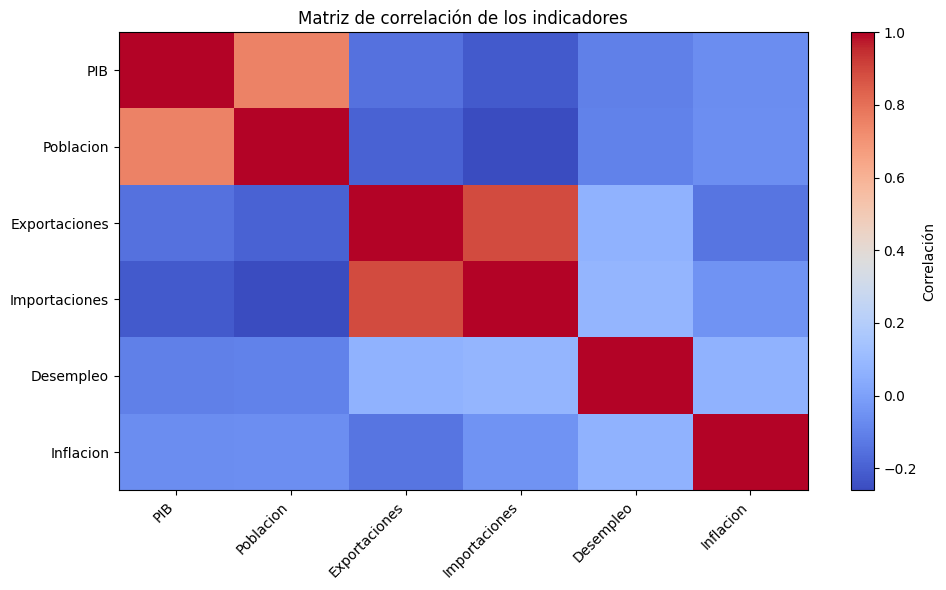

In [22]:
# Visualizar la matriz de correlación

plt.figure(figsize=(10, 6))

plt.imshow(correlacion, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Matriz de correlación de los indicadores")

plt.tight_layout()
plt.show()

**Variable objetivo**

In [23]:
# Definir variables predictoras y variable objetivo

X = df[
    [
        "Poblacion",
        "Exportaciones",
        "Importaciones",
        "Desempleo",
        "Inflacion"
    ]
]

y = df["PIB"]

print("Variables predictoras (X):")
print(X.columns.tolist())

print("\nVariable objetivo (y):")
print(y.name)

Variables predictoras (X):
['Poblacion', 'Exportaciones', 'Importaciones', 'Desempleo', 'Inflacion']

Variable objetivo (y):
PIB


In [24]:
# Dividir los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))

Datos de entrenamiento: 155
Datos de prueba: 39


**Modelo de Regresion Lineal**

In [25]:
# Crear el modelo de Regresión Lineal

modelo = LinearRegression()

print("Modelo de Regresión Lineal creado correctamente.")

Modelo de Regresión Lineal creado correctamente.


In [26]:
# Entrenar el modelo con los datos de entrenamiento

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


**Generar las predicciones**

In [27]:
# Generar predicciones sobre los datos de prueba

y_pred = modelo.predict(X_test)

print("Predicciones generadas correctamente.")
print(y_pred[:10])

Predicciones generadas correctamente.
[ 2.32456454e+12  1.17842314e+13  1.12103676e+12  1.35582591e+12
 -1.46669570e+11  2.99941081e+12  2.64747232e+12  6.20214589e+13
  1.50773244e+12  3.88481270e+12]


**Evaluar el modelo**

In [28]:
# Evaluar el modelo

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Resultados del modelo:")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²: {r2:.4f}")

Resultados del modelo:
MAE: 2,698,849,588,437.60
RMSE: 5,793,537,070,662.07
R²: 0.6138


**Comparar PIB real vs. PIB predicho**

In [29]:
# Comparar valores reales y predichos

comparacion = pd.DataFrame({
    "PIB_Real": y_test.values,
    "PIB_Predicho": y_pred
})

comparacion.head(10)

,PIB_Real,PIB_Predicho
0,1.794410e+12,2.324565e+12
1,1.650407e+12,1.178423e+13
2,4.314047e+10,1.121037e+12
3,1.938837e+10,1.355826e+12
4,2.504526e+09,-1.466696e+11
5,3.366863e+11,2.999411e+12
6,4.374153e+11,2.647472e+12
7,4.201133e+13,6.202146e+13
8,4.575105e+11,1.507732e+12
9,1.371167e+12,3.884813e+12


**Gráfico: PIB real vs. PIB predicho**

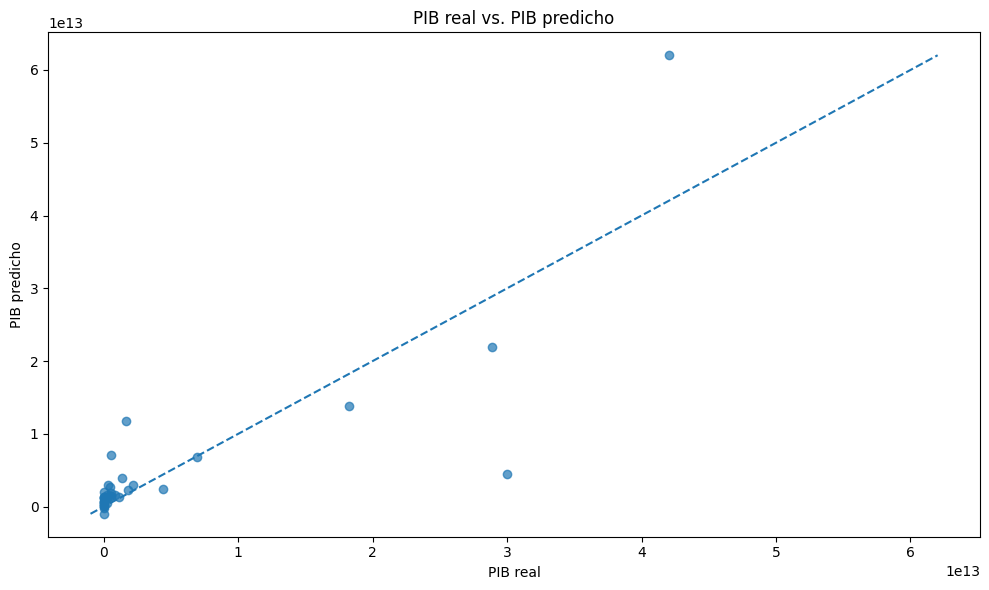

In [30]:
# Gráfico de PIB real vs PIB predicho

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("PIB real")
plt.ylabel("PIB predicho")
plt.title("PIB real vs. PIB predicho")

# Línea de referencia: predicción perfecta
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.tight_layout()
plt.show()

**Calcular los errores**

In [31]:
# Calcular los residuos del modelo

residuos = y_test - y_pred

print("Primeros residuos:")
print(residuos.head(10))

Primeros residuos:
138   -5.301542e+11
16    -1.013382e+13
155   -1.077896e+12
96    -1.336438e+12
68     1.491741e+11
153   -2.662724e+12
55    -2.210057e+12
15    -2.001013e+13
112   -1.050222e+12
111   -2.513646e+12
Name: PIB, dtype: float64


**Gráfico de residuos**

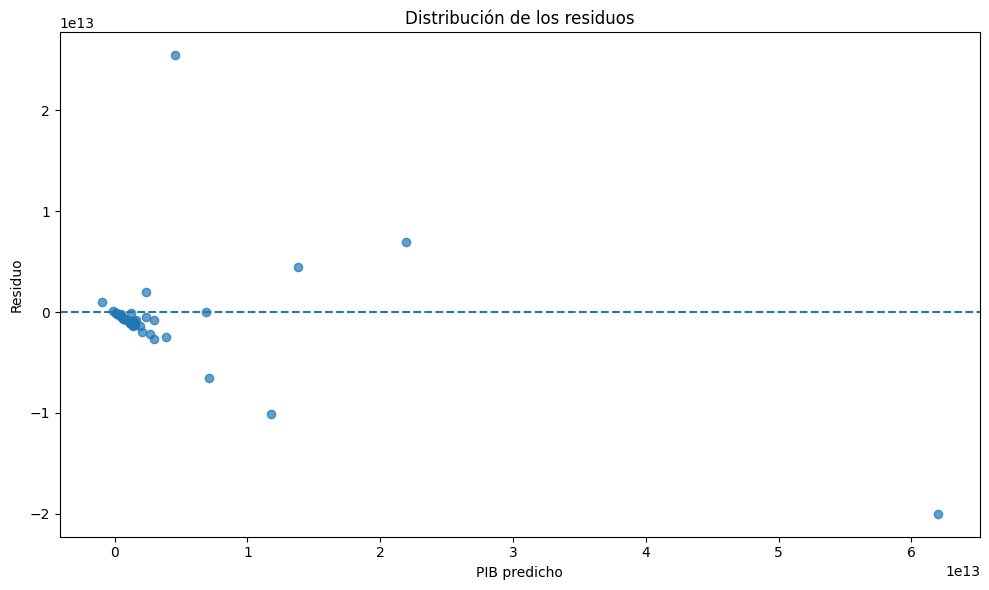

In [32]:
# Gráfico de residuos

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuos, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("PIB predicho")
plt.ylabel("Residuo")
plt.title("Distribución de los residuos")

plt.tight_layout()
plt.show()

**Distribución de los residuos**

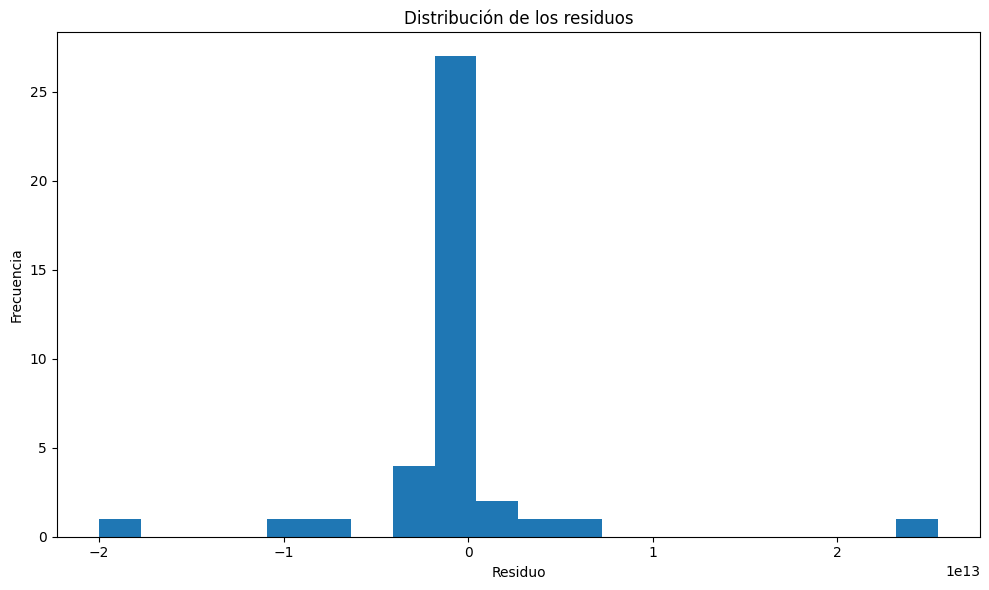

In [33]:
# Histograma de los residuos

plt.figure(figsize=(10, 6))

plt.hist(residuos, bins=20)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")

plt.tight_layout()
plt.show()

**Coeficientes del modelo**

In [34]:
# Obtener los coeficientes del modelo

coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})

coeficientes

,Variable,Coeficiente
0,Poblacion,8.874329e+03
1,Exportaciones,3.633660e+10
2,Importaciones,-4.290368e+10
3,Desempleo,-7.307832e+10
4,Inflacion,-3.925009e+09


## Interpretación de los coeficientes

Los coeficientes obtenidos por el modelo permiten identificar la relación estimada entre las variables predictoras y el Producto Interno Bruto (PIB), manteniendo constantes las demás variables.

La población presenta un coeficiente positivo, mientras que las exportaciones también muestran una relación positiva con el PIB. Por otro lado, importaciones, desempleo e inflación presentan coeficientes negativos.

Estos resultados corresponden a asociaciones estimadas por el modelo de regresión lineal y no deben interpretarse como relaciones causales. Además, las variables presentan diferentes unidades de medida, por lo que la magnitud de los coeficientes no debe utilizarse directamente para determinar cuál variable es más importante.

In [35]:
print("Intercepto del modelo:")
print(modelo.intercept_)

Intercepto del modelo:
1696275290325.2344


## Ecuación del modelo de regresión lineal

El modelo de regresión lineal obtenido permite estimar el Producto Interno Bruto (PIB) a partir de las variables población, exportaciones, importaciones, desempleo e inflación.

La ecuación estimada es:

**PIB = 1.696.275.290.325,23 + 8.874,33(Población) + 36.336.597.616,06(Exportaciones) - 42.903.676.680,53(Importaciones) - 73.078.316.626,97(Desempleo) - 3.925.009.177,30(Inflación)**

Los coeficientes representan la asociación estimada de cada variable con el PIB, manteniendo constantes las demás variables incluidas en el modelo.

In [37]:
resultados = df.loc[X_test.index, ["Codigo_Pais", "Pais"]].copy()

resultados["PIB_Real"] = y_test
resultados["PIB_Predicho"] = y_pred

resultados["Error_Absoluto"] = abs(
    resultados["PIB_Real"] - resultados["PIB_Predicho"]
)

resultados = resultados.sort_values(
    "Error_Absoluto",
    ascending=False
)

resultados.head(10)

,Codigo_Pais,Pais,PIB_Real,PIB_Predicho,Error_Absoluto
30,NAC,North America,3.001671e+13,4.549284e+12,2.546743e+13
15,IBT,IDA & IBRD total,4.201133e+13,6.202146e+13,2.001013e+13
16,IDX,IDA only,1.650407e+12,1.178423e+13,1.013382e+13
18,LTE,Late-demographic dividend,2.890944e+13,2.191591e+13,6.993527e+12
24,,Low income,5.567510e+11,7.075888e+12,6.519137e+12
75,CHN,China,1.827036e+13,1.383438e+13,4.435974e+12
153,PAK,Pakistan,3.366863e+11,2.999411e+12,2.662724e+12
111,IDN,Indonesia,1.371167e+12,3.884813e+12,2.513646e+12
55,BGD,Bangladesh,4.374153e+11,2.647472e+12,2.210057e+12
73,TCD,Chad,1.835294e+10,2.043234e+12,2.024881e+12


In [38]:
agregados = df[
    ~df["Codigo_Pais"].str.len().eq(3)
]

agregados[["Codigo_Pais", "Pais"]]

,Codigo_Pais,Pais
13,,High income
24,,Low income
25,,Lower middle income
42,,Upper middle income


In [39]:
agregados_codificados = df[
    df["Codigo_Pais"].isin(["NAC", "IBT", "IDX", "LTE"])
]

agregados_codificados[["Codigo_Pais", "Pais"]]

,Codigo_Pais,Pais
15,IBT,IDA & IBRD total
16,IDX,IDA only
18,LTE,Late-demographic dividend
30,NAC,North America


In [40]:
df_paises = df[
    ~df["Codigo_Pais"].isin(["IBT", "IDX", "LTE", "NAC"])
].copy()

df_paises = df_paises[
    df_paises["Codigo_Pais"].notna() &
    (df_paises["Codigo_Pais"] != "")
].copy()

print("Registros originales:", len(df))
print("Países individuales:", len(df_paises))

df_paises[["Codigo_Pais", "Pais"]].head()

Registros originales: 194
Países individuales: 186


,Codigo_Pais,Pais
0,AFE,Africa Eastern and Southern
1,ARB,Arab World
2,CEB,Central Europe and the Baltics
3,EAR,Early-demographic dividend
4,EAS,East Asia & Pacific


In [41]:
print("Total de registros:", len(df_paises))

df_paises[["Codigo_Pais", "Pais"]].to_string(index=False)

Total de registros: 186


"Codigo_Pais                                                                      Pais\n        AFE                                               Africa Eastern and Southern\n        ARB                                                                Arab World\n        CEB                                            Central Europe and the Baltics\n        EAR                                                Early-demographic dividend\n        EAS                                                       East Asia & Pacific\n        EAP                               East Asia & Pacific (excluding high income)\n        TEA                                East Asia & Pacific (IDA & IBRD countries)\n        EMU                                                                 Euro area\n        ECS                                                     Europe & Central Asia\n        ECA                             Europe & Central Asia (excluding high income)\n        TEC                              E

In [42]:
url_paises = "https://api.worldbank.org/v2/country?format=json&per_page=400"

respuesta_paises = requests.get(url_paises)
respuesta_paises.raise_for_status()

datos_paises = respuesta_paises.json()[1]

codigos_paises = {
    pais["id"]
    for pais in datos_paises
    if pais["region"]["id"] != "NA"
}

print("Códigos de países identificados:", len(codigos_paises))

Códigos de países identificados: 217


In [43]:
df_paises = df[
    df["Codigo_Pais"].isin(codigos_paises)
].copy()

print("Registros originales:", len(df))
print("Registros identificados como países/economías:", len(df_paises))

df_paises[["Codigo_Pais", "Pais"]].head(10)

Registros originales: 194
Registros identificados como países/economías: 150


,Codigo_Pais,Pais
44,AFG,Afghanistan
45,ALB,Albania
46,DZA,Algeria
47,AGO,Angola
48,ARG,Argentina
49,ARM,Armenia
50,AUS,Australia
51,AUT,Austria
52,AZE,Azerbaijan
53,BHS,"Bahamas, The"


In [44]:
df_paises.isnull().sum()

,0
Codigo_Pais,0
Pais,0
PIB,0
Poblacion,0
Exportaciones,0
Importaciones,0
Desempleo,0
Inflacion,0


In [45]:
X_paises = df_paises[
    [
        "Poblacion",
        "Exportaciones",
        "Importaciones",
        "Desempleo",
        "Inflacion"
    ]
]

y_paises = df_paises["PIB"]

print("Variables predictoras:")
print(X_paises.columns.tolist())

print("\nVariable objetivo:")
print(y_paises.name)

print("\nNúmero de observaciones:", len(df_paises))

Variables predictoras:
['Poblacion', 'Exportaciones', 'Importaciones', 'Desempleo', 'Inflacion']

Variable objetivo:
PIB

Número de observaciones: 150


In [46]:
X_train_paises, X_test_paises, y_train_paises, y_test_paises = train_test_split(
    X_paises,
    y_paises,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", len(X_train_paises))
print("Datos de prueba:", len(X_test_paises))

Datos de entrenamiento: 120
Datos de prueba: 30


In [48]:
modelo_paises = LinearRegression()

modelo_paises.fit(X_train_paises, y_train_paises)

print("Modelo de regresión lineal entrenado correctamente.")

Modelo de regresión lineal entrenado correctamente.


In [49]:
y_pred_paises = modelo_paises.predict(X_test_paises)

print("Predicciones generadas correctamente.")
print(y_pred_paises[:10])

Predicciones generadas correctamente.
[ 1.38816737e+12  1.58281978e+11  1.89704054e+11 -4.53263905e+11
  8.37064570e+11  8.59480003e+12  2.59044941e+11  8.86032888e+11
  9.59956452e+11  5.10988426e+10]


In [50]:
mae_paises = mean_absolute_error(y_test_paises, y_pred_paises)
rmse_paises = np.sqrt(mean_squared_error(y_test_paises, y_pred_paises))
r2_paises = r2_score(y_test_paises, y_pred_paises)

print("Resultados del modelo con países individuales:")
print(f"MAE: {mae_paises:,.2f}")
print(f"RMSE: {rmse_paises:,.2f}")
print(f"R²: {r2_paises:.4f}")

Resultados del modelo con países individuales:
MAE: 987,607,462,377.57
RMSE: 2,063,286,354,110.32
R²: 0.6333


## Evaluación del modelo

El modelo de regresión lineal fue evaluado utilizando 30 observaciones correspondientes al conjunto de prueba. Los resultados obtenidos fueron:

- **MAE:** US$987.607.462.377,57
- RMSE: US$2.063.286.354.110,32
- **R²:** 0,6333

El coeficiente de determinación (R²) indica que el modelo explica aproximadamente el 63,33 % de la variabilidad observada en el PIB de las economías incluidas en el conjunto de prueba. El 36,67 % restante corresponde a variaciones que no son explicadas por las variables utilizadas en el modelo.

El MAE y el RMSE presentan valores elevados debido a que el PIB está expresado en dólares estadounidenses y existen diferencias importantes en el tamaño económico de las economías analizadas.

In [51]:
comparacion_paises = df_paises.loc[
    X_test_paises.index,
    ["Codigo_Pais", "Pais"]
].copy()

comparacion_paises["PIB_Real"] = y_test_paises
comparacion_paises["PIB_Predicho"] = y_pred_paises

comparacion_paises["Error_Absoluto"] = abs(
    comparacion_paises["PIB_Real"] -
    comparacion_paises["PIB_Predicho"]
)

comparacion_paises.head(10)

,Codigo_Pais,Pais,PIB_Real,PIB_Predicho,Error_Absoluto
117,JPN,Japan,4.384854e+12,1.388167e+12,2.996687e+12
62,BIH,Bosnia and Herzegovina,2.759236e+10,1.582820e+11,1.306896e+11
162,RWA,Rwanda,1.480650e+10,1.897041e+11,1.748976e+11
122,KGZ,Kyrgyz Republic,1.518084e+10,-4.532639e+11,4.684447e+11
120,KOR,"Korea, Rep.",1.844801e+12,8.370646e+11,1.007736e+12
75,CHN,China,1.827036e+13,8.594800e+12,9.675557e+12
108,HUN,Hungary,2.130295e+11,2.590449e+11,4.601543e+10
185,UGA,Uganda,4.876896e+10,8.860329e+11,8.372639e+11
112,IRN,"Iran, Islamic Rep.",4.575105e+11,9.599565e+11,5.024460e+11
126,LBY,Libya,4.402766e+10,5.109884e+10,7.071178e+09


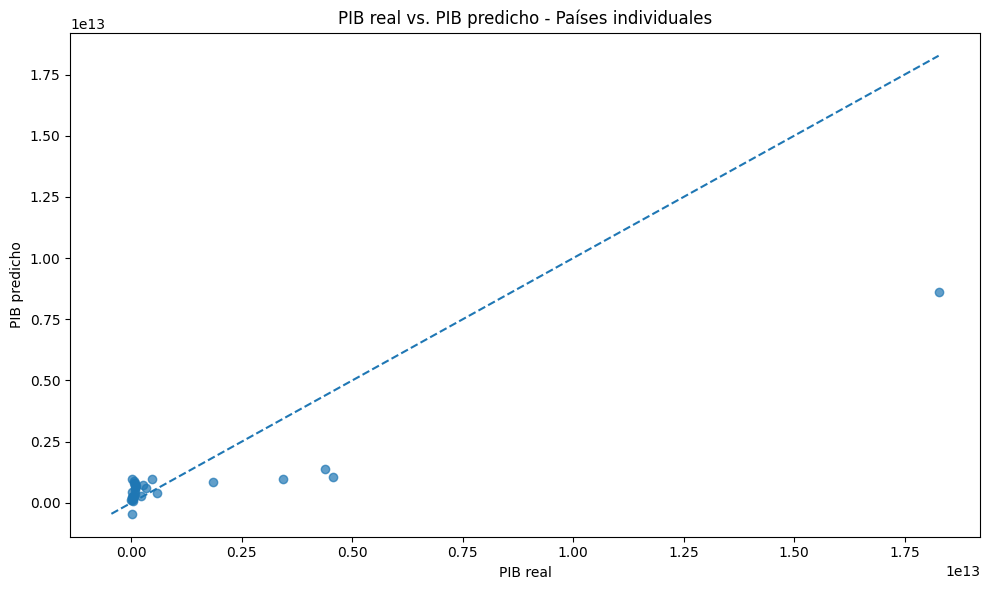

In [52]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_paises,
    y_pred_paises,
    alpha=0.7
)

limite_min = min(
    y_test_paises.min(),
    y_pred_paises.min()
)

limite_max = max(
    y_test_paises.max(),
    y_pred_paises.max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--"
)

plt.xlabel("PIB real")
plt.ylabel("PIB predicho")
plt.title("PIB real vs. PIB predicho - Países individuales")
plt.tight_layout()
plt.show()

In [53]:
residuos_paises = y_test_paises - y_pred_paises

print("Primeros residuos:")
print(residuos_paises.head(10))

Primeros residuos:
117    2.996687e+12
62    -1.306896e+11
162   -1.748976e+11
122    4.684447e+11
120    1.007736e+12
75     9.675557e+12
108   -4.601543e+10
185   -8.372639e+11
112   -5.024460e+11
126   -7.071178e+09
Name: PIB, dtype: float64


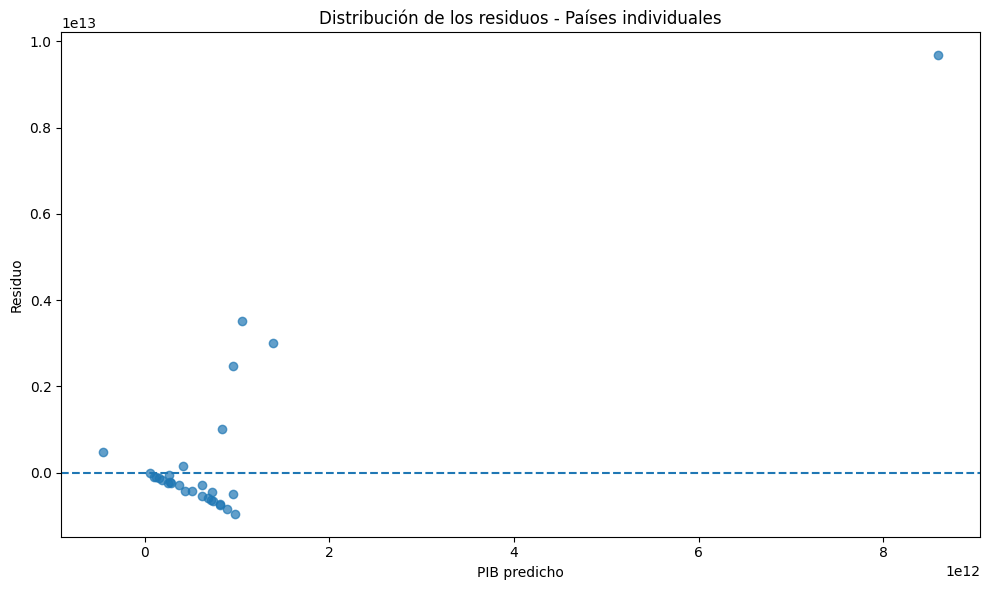

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_paises,
    residuos_paises,
    alpha=0.7
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("PIB predicho")
plt.ylabel("Residuo")
plt.title("Distribución de los residuos - Países individuales")
plt.tight_layout()
plt.show()

**Histograma de residuos**

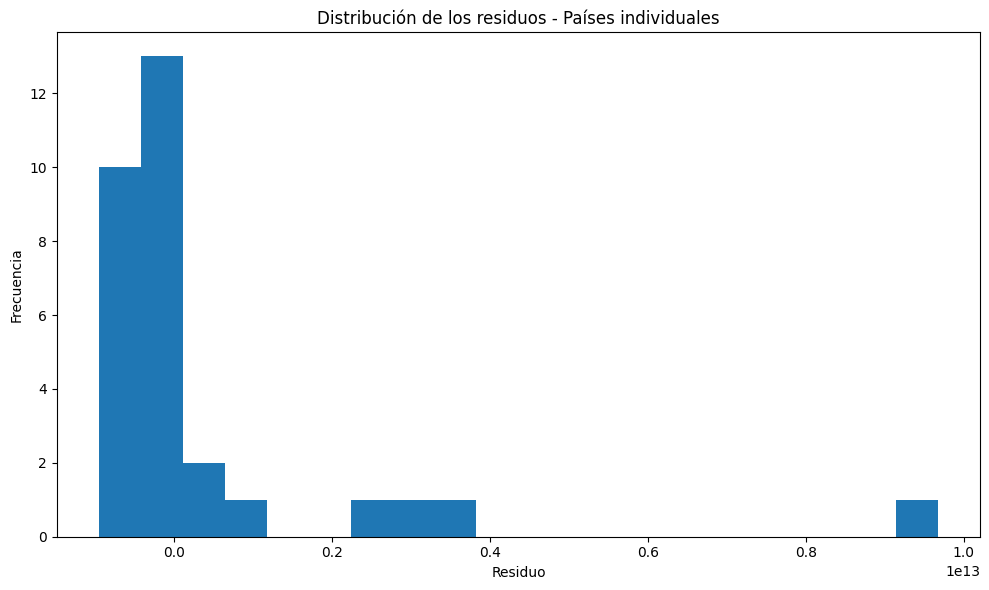

In [55]:
plt.figure(figsize=(10, 6))

plt.hist(residuos_paises, bins=20)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos - Países individuales")
plt.tight_layout()
plt.show()

In [56]:
coeficientes_paises = pd.DataFrame({
    "Variable": X_paises.columns,
    "Coeficiente": modelo_paises.coef_
})

coeficientes_paises

,Variable,Coeficiente
0,Poblacion,5.570377e+03
1,Exportaciones,9.040080e+09
2,Importaciones,-1.773811e+10
3,Desempleo,-2.053246e+10
4,Inflacion,-2.411009e+09


In [57]:
intercepto_paises = modelo_paises.intercept_

print(f"Intercepto del modelo: {intercepto_paises:,.2f}")

Intercepto del modelo: 965,190,768,680.37


In [58]:
print("Ecuación del modelo de regresión lineal:\n")

print(
    f"PIB = {modelo_paises.intercept_:.2f}"
    f" + ({modelo_paises.coef_[0]:.2f} × Poblacion)"
    f" + ({modelo_paises.coef_[1]:.2f} × Exportaciones)"
    f" + ({modelo_paises.coef_[2]:.2f} × Importaciones)"
    f" + ({modelo_paises.coef_[3]:.2f} × Desempleo)"
    f" + ({modelo_paises.coef_[4]:.2f} × Inflacion)"
)

Ecuación del modelo de regresión lineal:

PIB = 965190768680.37 + (5570.38 × Poblacion) + (9040080326.00 × Exportaciones) + (-17738110395.52 × Importaciones) + (-20532457424.70 × Desempleo) + (-2411008923.12 × Inflacion)


In [59]:
df_paises.to_csv(
    "dataset_regresion_pib_2023_limpio.csv",
    index=False
)

print("Dataset limpio guardado correctamente.")
print(f"Filas: {df_paises.shape[0]}")
print(f"Columnas: {df_paises.shape[1]}")

Dataset limpio guardado correctamente.
Filas: 150
Columnas: 8


In [60]:
from google.colab import files

files.download("dataset_regresion_pib_2023_limpio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>